In [10]:
import yaml
from typing import Any
from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler
from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph
from IPython.display import Image as IPyImage, display

def assert_true(condition: bool, message: str) -> bool:
    if not condition: raise AssertionError(message)
    return True

def validate_call(test_name: str, expected_success: bool, func: Any, *args: Any, **kwargs: Any) -> Any:
    try:
        result = func(*args, **kwargs)
        if expected_success:
            print(f"[bold green]PASS:[/bold green] {test_name}")
            return result
        else:
            print(f"[bold red]FAIL:[/bold red] {test_name} (Expected error, got success)")
            return None
    except Exception as e:
        if not expected_success:
            print(f"[bold green]PASS (Error Caught):[/bold green] {test_name} -> {type(e).__name__}: {e}")
            return None
        else:
            print(f"[bold red]FAIL:[/bold red] {test_name} -> Unexpected Error: {type(e).__name__}: {e}")
            return None


In [11]:
import os
from dotenv import load_dotenv
import yaml
from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig
from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph

load_dotenv()
TOMTOM_API_KEY = os.getenv("TOMTOM_API_KEY")

# Load configurations and instantiate baseline components
with open('configs/iligan_configs.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

city_graph_cfg = cfg["city_graph"]
city = CityGraph(
    bbox=tuple(city_graph_cfg["bbox"]),
    name=city_graph_cfg["name"],
    landmarks=city_graph_cfg["landmarks"],
    pbf_path=city_graph_cfg["pbf_path"],
    use_api=False,
    verbose=True
)

sampler = DirectDemandSampler(
    city=city,
    config=DDMConfig(**cfg["ddm"]),
    only_drivable=True
)

generator = RouteGenerator(
    city_graph=city,
    sampler=sampler
)

tg = TravelGraph(
    cg=city,
    route_generator=generator,
    config=cfg["travel_graph"],
    n_routes=20,
    n_points=5
)


[CITY GRAPH] Loading graph from binary cache.


[CITY GRAPH] Building edges: 100%|██████████| 75761/75761 [00:00<00:00, 147542.65it/s]


## 1. Passenger Diagnostics

PASS (Error Caught): Passenger reject negative speed -> ValueError: [PASSENGER] speed cannot be negative.

PASS (Error Caught): Passenger reject invalid coords -> ValueError: could not convert string to float: 'lat'

PASS: Passenger initialization

FAIL: Passenger transitions to WAITING -> Unexpected Error: AssertionError: Current state: WALKING

PASS: Passenger draw returns square Image

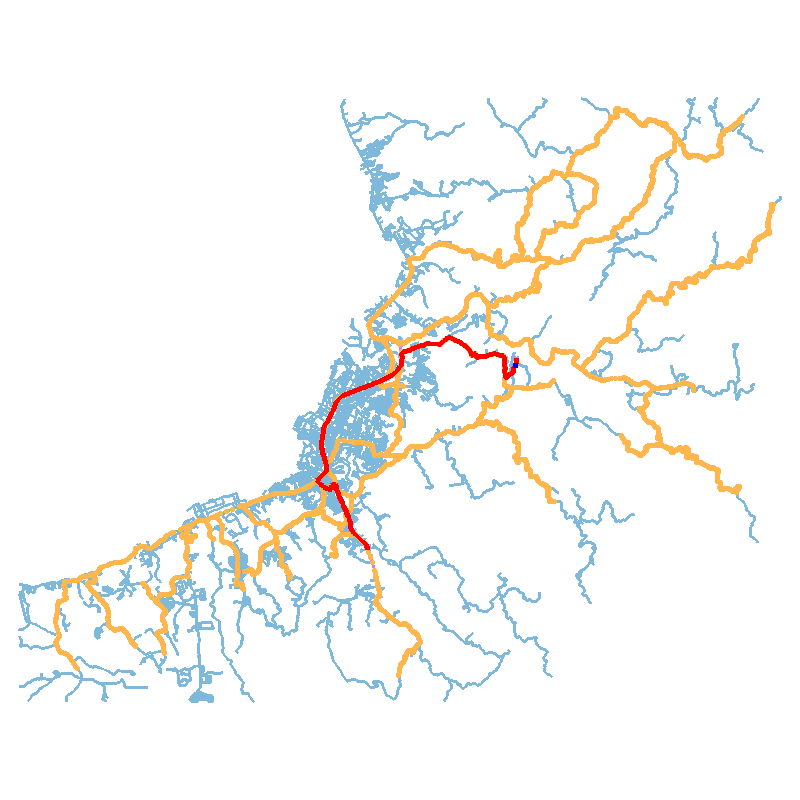

In [12]:
from utils.passenger import Passenger
import random

if tg and city:
    start_node, end_node = random.sample(city.nodes, 2)
    journey = tg.findShortestJourney(start_node, end_node)
    
    if journey:
        # Negative Tests
        validate_call("Passenger reject negative speed", False, Passenger, start_pos=(start_node.lon, start_node.lat), journey=journey, speed=-5.0)
        validate_call("Passenger reject invalid coords", False, Passenger, start_pos=("lat", "lon"), journey=journey, speed=5.0)
        
        # Positive Test
        p = validate_call("Passenger initialization", True, Passenger, start_pos=(start_node.lon, start_node.lat), journey=journey, speed=5.0)
        
        if p:
            # Simulate walking to waiting
            initial_state = p.state
            for _ in range(50):
                p.update()
                if p.state == "WAITING":
                    break
            validate_call("Passenger transitions to WAITING", True, assert_true, p.state == "WAITING", f"Current state: {p.state}")
            
            # Visualization test
            base_img = tg.draw(city.get_bounds(), city.draw(size=800, only_drivable=False), journey=journey, display_walk=True, display_wait=True, display_ride=True)
            pass_img = p.draw(city.get_bounds(), base_img.copy())
            validate_call("Passenger draw returns square Image", True, assert_true, pass_img.width == pass_img.height, "Image not square.")
            display(pass_img)


## 2. Jeep Diagnostics

PASS (Error Caught): Jeep reject negative speed -> ValueError: [JEEP] speed cannot be negative.

PASS: Jeep initialization

PASS: Jeep draw returns square Image

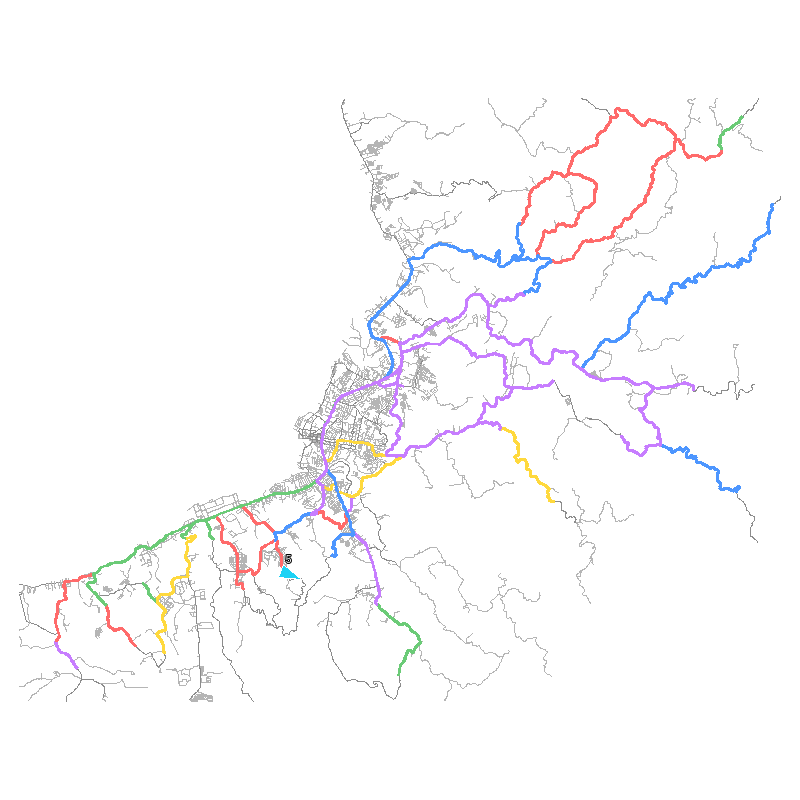

In [13]:
from utils.jeep import Jeep

if tg and tg.routes:
    route = tg.routes[0]
    start_coord = (route.path[0].start.lon, route.path[0].start.lat)
    
    # Negative Tests
    validate_call("Jeep reject negative speed", False, Jeep, route=route, curr_pos=start_coord, speed=-10.0)
    
    # Positive Test
    j = validate_call("Jeep initialization", True, Jeep, route=route, curr_pos=start_coord, speed=10.0, max_capacity=16)
    
    if j:
        # Move jeep
        for _ in range(10):
            j.update()
            
        # Visualization test
        # base_img = route.draw(city.get_bounds(), city.draw(size=800, only_drivable=False), highlight=True)
        base_img = tg.draw(city.get_bounds(), city.draw(size=800, only_drivable=False), display_ride=True)
        j.curr_passenger_count = 5 # Mock some passengers
        jeep_img = j.draw(city.get_bounds(), base_img.copy())
        validate_call("Jeep draw returns square Image", True, assert_true, jeep_img.width == jeep_img.height, "Image not square.")
        display(jeep_img)


## 3. FleetAllocator & JeepSystem Diagnostics

In [14]:
from utils.jeep_system import JeepSystem, FleetAllocator

if tg and sampler and tg.routes:
    # Negative Test
    validate_call("FleetAllocator reject empty routes", False, FleetAllocator.allocate_by_mohring, total_fleet=10, routes=[], sampler=sampler, tg=tg)
    validate_call("JeepSystem reject empty jeeps", False, JeepSystem, jeeps=[], routes=tg.routes)
    
    # Positive Test: Mohring Allocation
    allocation = validate_call(
        "Mohring Allocation", True, FleetAllocator.allocate_by_mohring, 
        total_fleet=10, routes=tg.routes, sampler=sampler, tg=tg, mohring_sample_size=100
    )
    
    if allocation:
        validate_call("Allocation sums to total fleet", True, assert_true, sum(allocation.values()) == 10, "Sum mismatch.")
        
        # Create JeepSystem
        jeeps = []
        for r, count in allocation.items():
            start_coord = (r.path[0].start.lon, r.path[0].start.lat)
            for _ in range(count):
                jeeps.append(Jeep(r, start_coord, 10.0))
                
        sys = validate_call("JeepSystem initialization", True, JeepSystem, jeeps=jeeps, routes=tg.routes)


PASS (Error Caught): FleetAllocator reject empty routes -> ValueError: [FLEET ALLOCATOR] Routes list cannot be 
empty.

PASS (Error Caught): JeepSystem reject empty jeeps -> ValueError: [JEEP SYSTEM] jeeps list cannot be empty.

PASS: Mohring Allocation

FAIL: Allocation sums to total fleet -> Unexpected Error: AssertionError: Sum mismatch.

PASS: JeepSystem initialization

## 4. PassengerGenerator Diagnostics

In [15]:
from utils.passenger_generator import PassengerGenerator

if tg and sampler:
    # Negative Tests
    validate_call("PassengerGenerator reject negative rate", False, PassengerGenerator, tg=tg, sampler=sampler, rate_per_100=-5.0, stdev=1.0)
    validate_call("PassengerGenerator reject null tg", False, PassengerGenerator, tg=None, sampler=sampler, rate_per_100=50.0, stdev=10.0)
    
    # Positive Test
    pgen = validate_call("PassengerGenerator initialization", True, PassengerGenerator, tg=tg, sampler=sampler, rate_per_100=50.0, stdev=10.0)
    
    if pgen:
        # Run for 100 ticks
        for _ in range(100):
            pgen.update()
            
        validate_call("PassengerGenerator spawned passengers", True, assert_true, len(pgen.passengers) > 0 or len(pgen.archived_passengers) > 0, "No passengers generated.")
        print(f"Generated {len(pgen.passengers)} active, {len(pgen.archived_passengers)} archived in 100 ticks.")


PASS (Error Caught): PassengerGenerator reject negative rate -> ValueError: [PASSENGER GENERATOR] rate_per_100 
cannot be negative.

PASS (Error Caught): PassengerGenerator reject null tg -> ValueError: [PASSENGER GENERATOR] TravelGraph cannot be 
None.

PASS: PassengerGenerator initialization

PASS: PassengerGenerator spawned passengers

Generated 55 active, 0 archived in 100 ticks.

## 5. Simulation Stack Diagnostics

In [16]:
from utils.simulation import SimulationSetup

if city and cfg and tg.routes:
    # Negative Test: No routes
    validate_call("SimulationSetup reject empty routes", False, SimulationSetup, city_query=city.query, config=cfg, routes=[])
    
    # Positive Test
    setup = validate_call("SimulationSetup initialization", True, SimulationSetup, city_query=city.query, config=cfg, routes=tg.routes)
    
    if setup:
        sim = validate_call("Simulation build", True, setup.build, visualizer=False)
        
        if sim:
            sim.max_ticks = 50 # Run short sim
            result = validate_call("Simulation run", True, sim.run)
            
            if result:
                validate_call("Simulation metrics generated", True, assert_true, 'fitness_score' in result.__dict__, "Metrics missing.")
                print("Fitness Score:", result.fitness_score)
                print("Metrics:", result.metrics)
                
                # Export snapshot (will save to disk and print path)
                sim.export_snapshot("utils/.cache/sim_snapshot_demo.png")
                print("Wait a moment for the async render to complete...")


ImportError: cannot import name 'StaticTravelGraph' from 'utils.travel_graph' (c:\Users\lifei\OneDrive\Desktop\Portfolio\Jeepney-Route-System-Optimization\utils\travel_graph.py)